# Установка зависимостей

In [ ]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

# Импорт

In [26]:
import numpy as np
from keras.datasets import imdb
from keras import models, layers
import matplotlib.pyplot as plt
import pandas as pd
from keras.preprocessing.sequence import pad_sequences
from keras import regularizers

# Загрузка данных

In [2]:
def load_data(num_words=10000):
    (train_data, train_targets), (test_data, test_targets) = imdb.load_data(num_words=num_words)

    data = np.concatenate((train_data, test_data), axis=0)
    targets = np.concatenate((train_targets, test_targets), axis=0)

    return data, targets

In [27]:
data, targets = load_data(num_words=10000)
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Анализ данных

In [28]:
print("Категории:", np.unique(targets))
print("Количество уникальных слов:", len(np.unique(np.hstack(data))), end=3*'\n')

df = pd.DataFrame({
    'review_length': [len(review) for review in data],
    'sentiment': targets
})

print(df['review_length'].describe(), end=3*'\n')
print(df.groupby('sentiment')['review_length'].describe())

Категории: [0 1]
Количество уникальных слов: 9998


count    50000.000000
mean       234.758920
std        172.913224
min          7.000000
25%        129.000000
50%        176.000000
75%        285.000000
max       2494.000000
Name: review_length, dtype: float64


             count       mean         std   min    25%    50%    75%     max
sentiment                                                                   
0          25000.0  233.33536  166.728226   7.0  130.0  177.0  282.0  1571.0
1          25000.0  236.18248  178.876514  10.0  127.0  175.0  287.0  2494.0


In [29]:
print("Label:", targets[0])
print(data[0])

Label: 1
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [30]:
print(word_index)
print(len(word_index))

{'fawn': 34701, 'tsukino': 52006, 'nunnery': 52007, 'sonja': 16816, 'vani': 63951, 'woods': 1408, 'spiders': 16115, 'hanging': 2345, 'woody': 2289, 'trawling': 52008, "hold's": 52009, 'comically': 11307, 'localized': 40830, 'disobeying': 30568, "'royale": 52010, "harpo's": 40831, 'canet': 52011, 'aileen': 19313, 'acurately': 52012, "diplomat's": 52013, 'rickman': 25242, 'arranged': 6746, 'rumbustious': 52014, 'familiarness': 52015, "spider'": 52016, 'hahahah': 68804, "wood'": 52017, 'transvestism': 40833, "hangin'": 34702, 'bringing': 2338, 'seamier': 40834, 'wooded': 34703, 'bravora': 52018, 'grueling': 16817, 'wooden': 1636, 'wednesday': 16818, "'prix": 52019, 'altagracia': 34704, 'circuitry': 52020, 'crotch': 11585, 'busybody': 57766, "tart'n'tangy": 52021, 'burgade': 14129, 'thrace': 52023, "tom's": 11038, 'snuggles': 52025, 'francesco': 29114, 'complainers': 52027, 'templarios': 52125, '272': 40835, '273': 52028, 'zaniacs': 52130, '275': 34706, 'consenting': 27631, 'snuggled': 408

In [31]:
reverse_index = {value: key for key, value in word_index.items()}
dict(sorted(reverse_index.items()))

{1: 'the',
 2: 'and',
 3: 'a',
 4: 'of',
 5: 'to',
 6: 'is',
 7: 'br',
 8: 'in',
 9: 'it',
 10: 'i',
 11: 'this',
 12: 'that',
 13: 'was',
 14: 'as',
 15: 'for',
 16: 'with',
 17: 'movie',
 18: 'but',
 19: 'film',
 20: 'on',
 21: 'not',
 22: 'you',
 23: 'are',
 24: 'his',
 25: 'have',
 26: 'he',
 27: 'be',
 28: 'one',
 29: 'all',
 30: 'at',
 31: 'by',
 32: 'an',
 33: 'they',
 34: 'who',
 35: 'so',
 36: 'from',
 37: 'like',
 38: 'her',
 39: 'or',
 40: 'just',
 41: 'about',
 42: "it's",
 43: 'out',
 44: 'has',
 45: 'if',
 46: 'some',
 47: 'there',
 48: 'what',
 49: 'good',
 50: 'more',
 51: 'when',
 52: 'very',
 53: 'up',
 54: 'no',
 55: 'time',
 56: 'she',
 57: 'even',
 58: 'my',
 59: 'would',
 60: 'which',
 61: 'only',
 62: 'story',
 63: 'really',
 64: 'see',
 65: 'their',
 66: 'had',
 67: 'can',
 68: 'were',
 69: 'me',
 70: 'well',
 71: 'than',
 72: 'we',
 73: 'much',
 74: 'been',
 75: 'bad',
 76: 'get',
 77: 'will',
 78: 'do',
 79: 'also',
 80: 'into',
 81: 'people',
 82: 'other',
 8

**Служебные токены:**
*   0 - padding (выравнивание длины)
*   1 - start (начало текста)
*   2 - unknown (неизвестное слово)
*   3 - unused (зарезервировано)








In [32]:
def decode_review(encoded_review, word_index):
    reverse_index = {value: key for key, value in word_index.items()}
    return " ".join([reverse_index.get(i - 3, "#") for i in encoded_review])

In [33]:
decode_review(data[0], word_index)

"# this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert # is an amazing actor and now the same being director # father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for # and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also # to the two little boy's that played the # of norman and paul they were just brilliant children are often left out of the # list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

# Предобработка данных

In [34]:
def split_data(data, targets, test_size=5000):
    x_test = data[:test_size]
    y_test = targets[:test_size]

    x_train = data[test_size:]
    y_train = targets[test_size:]

    return x_train, y_train, x_test, y_test

In [35]:
def vectorize_sequences(sequences, dimension=10000):
  result = np.zeros((len(sequences), dimension), dtype=np.float32)
  for i, sequence in enumerate(sequences):
      result[i, sequence] = 1.0
  return result

In [36]:
def padding_sequences(sequences, max_len=250):
  return pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [37]:
data = vectorize_sequences(data)
targets = np.array(targets).astype("float32")

x_train, y_train, x_test, y_test = split_data(data, targets)

# Создание модели

In [38]:
def build_model(input_dim):
    model = models.Sequential()

    model.add(layers.Dense(64, activation="relu", input_shape=(input_dim,)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(32, activation="relu"))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [39]:
def build_embedding_model(num_words, max_len=250):
    model = models.Sequential()

    model.add(layers.Embedding(
        input_dim=num_words,
        output_dim=128,
        input_length=max_len
    ))

    model.add(layers.GlobalAveragePooling1D())

    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(64, activation="relu"))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [40]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # График точности
    axes[0].plot(history.history['accuracy'], label='Обучение')
    axes[0].plot(history.history['val_accuracy'], label='Валидация')

    axes[0].set_title('Точность (Accuracy)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[0].text(0.02, 0.02,
                 f"Train: {history.history['accuracy'][-1]:.3f}\n"
                 f"Val: {history.history['val_accuracy'][-1]:.3f}",
                 transform=axes[0].transAxes,
                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    # График потерь
    axes[1].plot(history.history['loss'], label='Обучение')
    axes[1].plot(history.history['val_loss'], label='Валидация')

    axes[1].set_title('Потери (Loss)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[1].text(0.02, 0.95,
                 f"Train: {history.history['loss'][-1]:.3f}\n"
                 f"Val: {history.history['val_loss'][-1]:.3f}",
                 transform=axes[1].transAxes,
                 bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

    plt.tight_layout()
    plt.show()

#  Обучение модели

In [41]:
model = build_model(10000)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,337 (2.47 MB)

 Trainable params: 646,337 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
        x_train,
        y_train,
        epochs=2,
        batch_size=500,
        validation_split=0.1,
        verbose=1
    )
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Тестовая точность: {test_acc:.4f}")
print(f"Тестовые потери: {test_loss:.4f}")

Epoch 1/2
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8222 - loss: 0.4011 - val_accuracy: 0.8984 - val_loss: 0.2556
Epoch 2/2
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9168 - loss: 0.2159 - val_accuracy: 0.8998 - val_loss: 0.2530
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8952 - loss: 0.2618
Тестовая точность: 0.8952
Тестовые потери: 0.2618


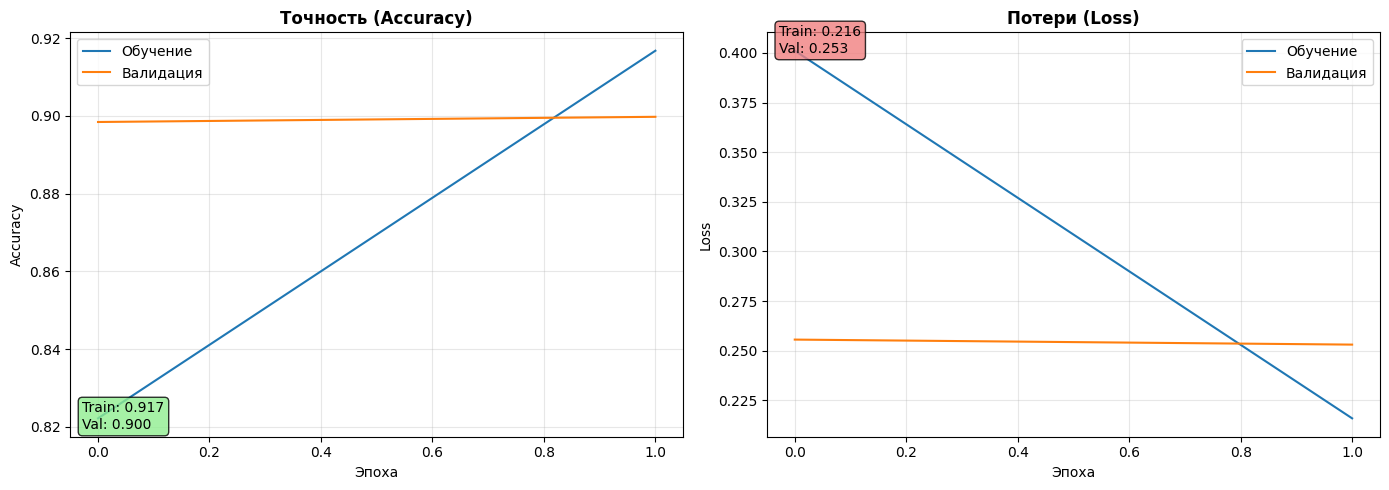

In [43]:
plot_training_history(history)

# Исследование

In [44]:
def run_experiment(num_words_list):
    results = {}

    for dim in num_words_list:
        print(f"Размер словаря: {dim}")

        data, targets = load_data(num_words=dim)
        data = vectorize_sequences(data, dimension=dim)
        targets = np.array(targets).astype("float32")
        x_train, y_train, x_test, y_test = split_data(data, targets)

        model = build_model(dim)
        history = model.fit(
            x_train, y_train,
            epochs=3,
            batch_size=512,
            validation_split=0.1,
            verbose=1
        )

        test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
        print(f"Точность на тесте: {test_acc:.4f}, Потери: {test_loss:.4f}")

        results[dim] = {
            "history": history,
            "test_acc": test_acc,
            "test_loss": test_loss
        }

    return results

In [50]:
def run_embedding_experiment(num_words_list, max_len=250):
    results = {}

    for dim in num_words_list:
        print(f"Размер словаря: {dim}")

        data, targets = load_data(num_words=dim)
        data = padding_sequences(data, max_len=max_len)
        targets = np.array(targets).astype("float32")
        x_train, y_train, x_test, y_test = split_data(data, targets)

        model = build_embedding_model(dim, max_len)

        history = model.fit(
            x_train, y_train,
            epochs=6,
            batch_size=512,
            validation_split=0.1,
            verbose=1
        )

        test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

        print(f"Точность на тесте: {test_acc:.4f}, Потери: {test_loss:.4f}")

        results[dim] = {
            "history": history,
            "test_acc": test_acc,
            "test_loss": test_loss
        }

    return results

In [46]:
num_words_list = [2000, 5000, 10000, 15000]
results = run_experiment(num_words_list)

Размер словаря: 2000
Epoch 1/3
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7788 - loss: 0.4583 - val_accuracy: 0.8762 - val_loss: 0.2947
Epoch 2/3
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8785 - loss: 0.2926 - val_accuracy: 0.8824 - val_loss: 0.2801
Epoch 3/3
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8950 - loss: 0.2581 - val_accuracy: 0.8804 - val_loss: 0.2848
Точность на тесте: 0.8736, Потери: 0.2973
Размер словаря: 5000
Epoch 1/3
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.8101 - loss: 0.4179 - val_accuracy: 0.8900 - val_loss: 0.2659
Epoch 2/3
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9040 - loss: 0.2455 - val_accuracy: 0.8851 - val_loss: 0.2830
Epoch 3/3
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9238 - loss: 0.1992 - val_accuracy: 0.8927 - val_loss: 0.2674
Точность на тесте: 0.8900, Потери: 0.2699
Размер словаря: 10000
Epoch 1/3
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.8099 - loss: 0.4146 - val_accura

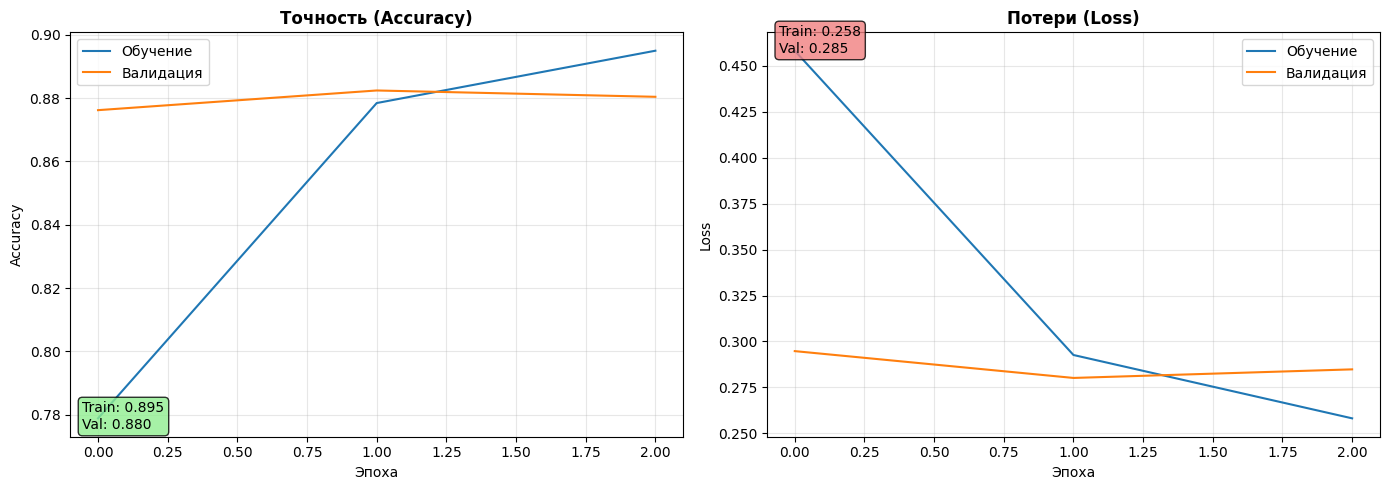

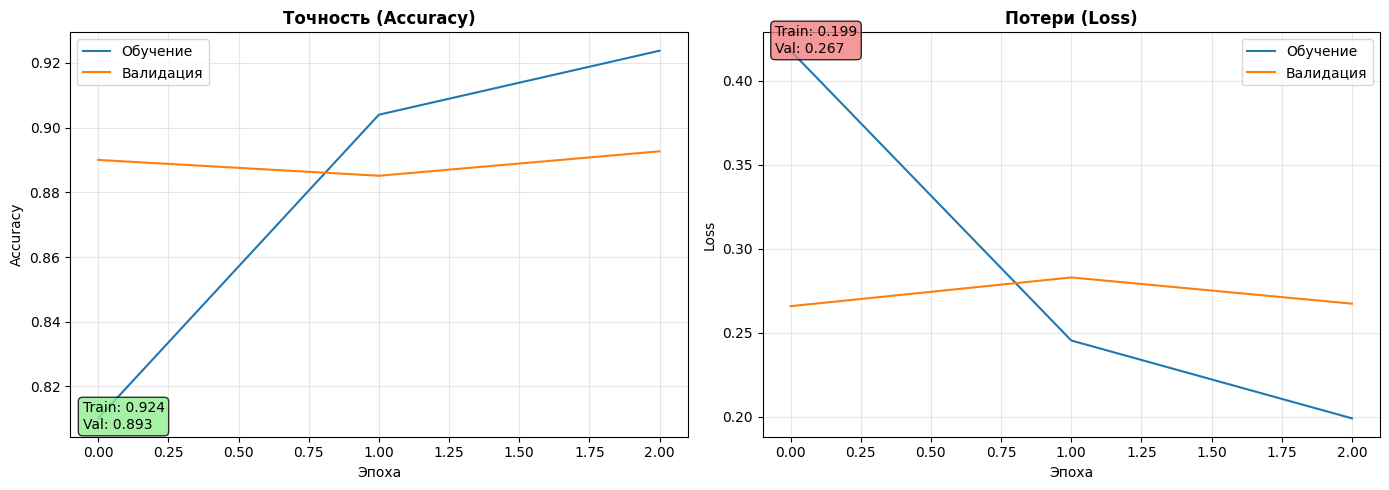

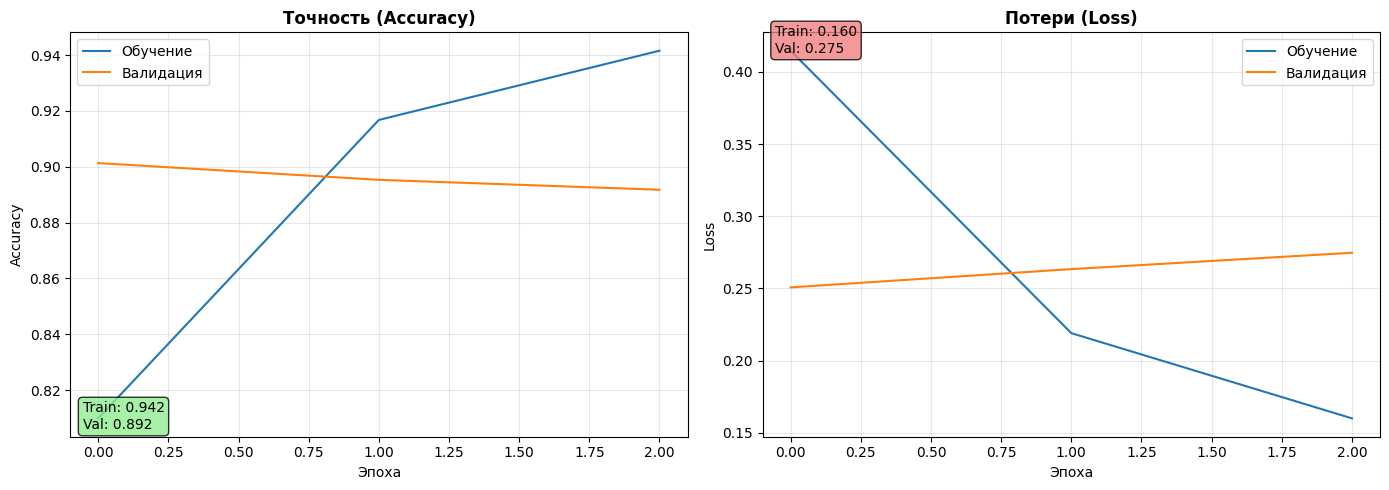

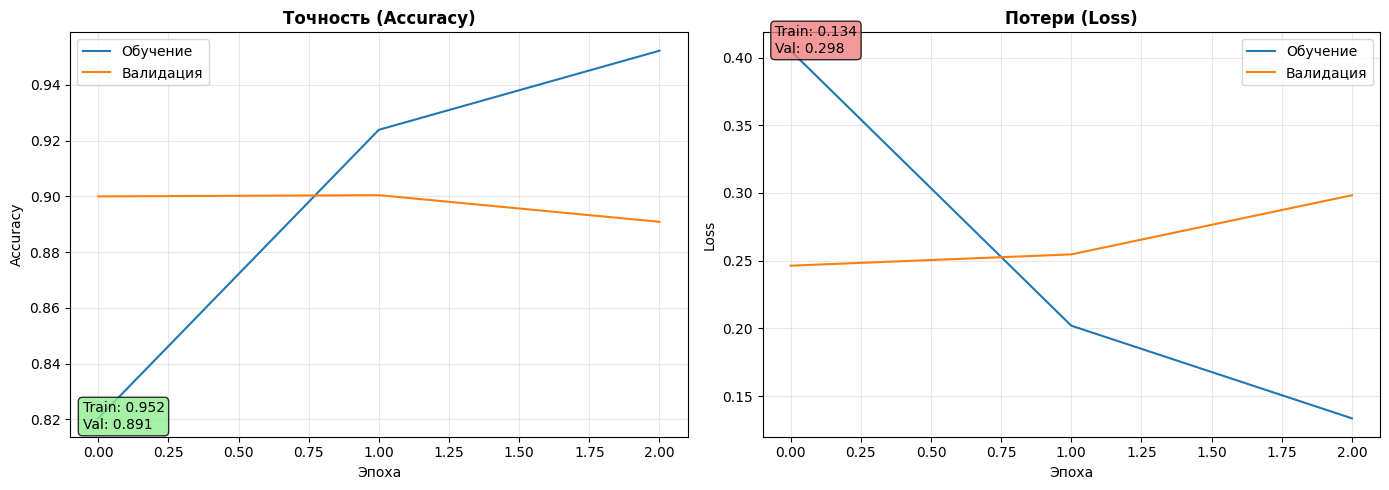

In [47]:
for dim in num_words_list:
  plot_training_history(results[dim]["history"])

In [52]:
num_words_list = [2000, 5000, 10000, 15000]
results = run_embedding_experiment(num_words_list, max_len=300)

Размер словаря: 2000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 191ms/step - accuracy: 0.6342 - loss: 0.6249 - val_accuracy: 0.7638 - val_loss: 0.4636
Epoch 2/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - accuracy: 0.8095 - loss: 0.4163 - val_accuracy: 0.8076 - val_loss: 0.3996
Epoch 3/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 203ms/step - accuracy: 0.8381 - loss: 0.3680 - val_accuracy: 0.6469 - val_loss: 0.9491
Epoch 4/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - accuracy: 0.8113 - loss: 0.4315 - val_accuracy: 0.8582 - val_loss: 0.3230
Epoch 5/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 196ms/step - accuracy: 0.8609 - loss: 0.3288 - val_accuracy: 0.8473 - val_loss: 0.3428
Epoch 6/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.8722 - loss: 0.3051 - val_accuracy: 0.8138 - val_loss: 0.4210
Точность на тесте: 0.8138, Потери: 0.4286
Размер словаря: 5000
Epoch 1/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 263ms/step - accuracy: 0.6361 - loss: 0.6261 - val_accuracy: 0.7460 - val_loss: 0.4890
Epoch 2/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 

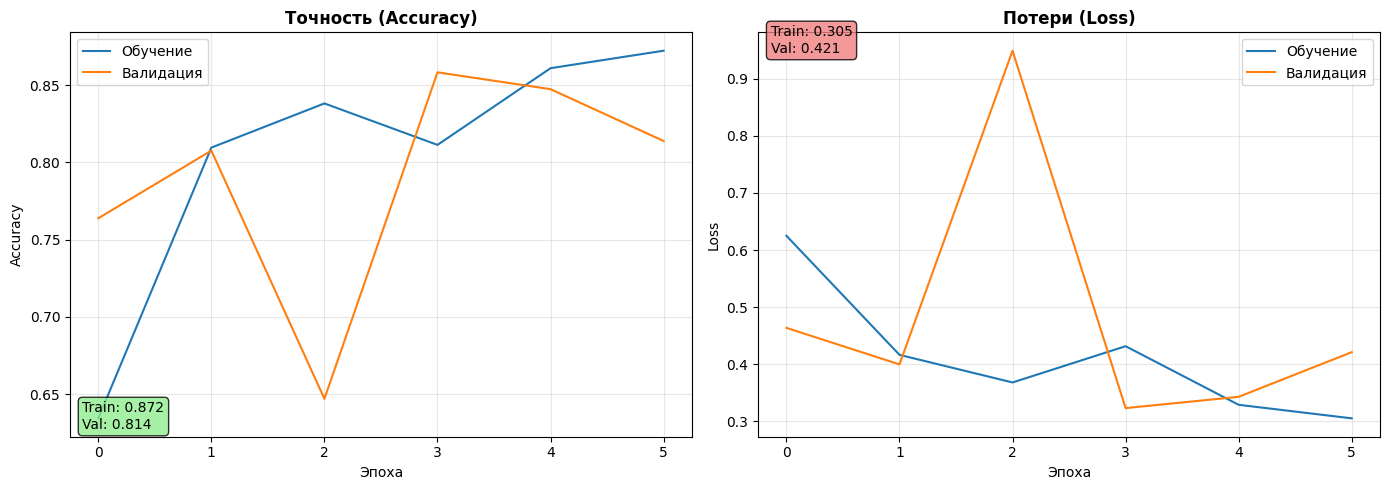

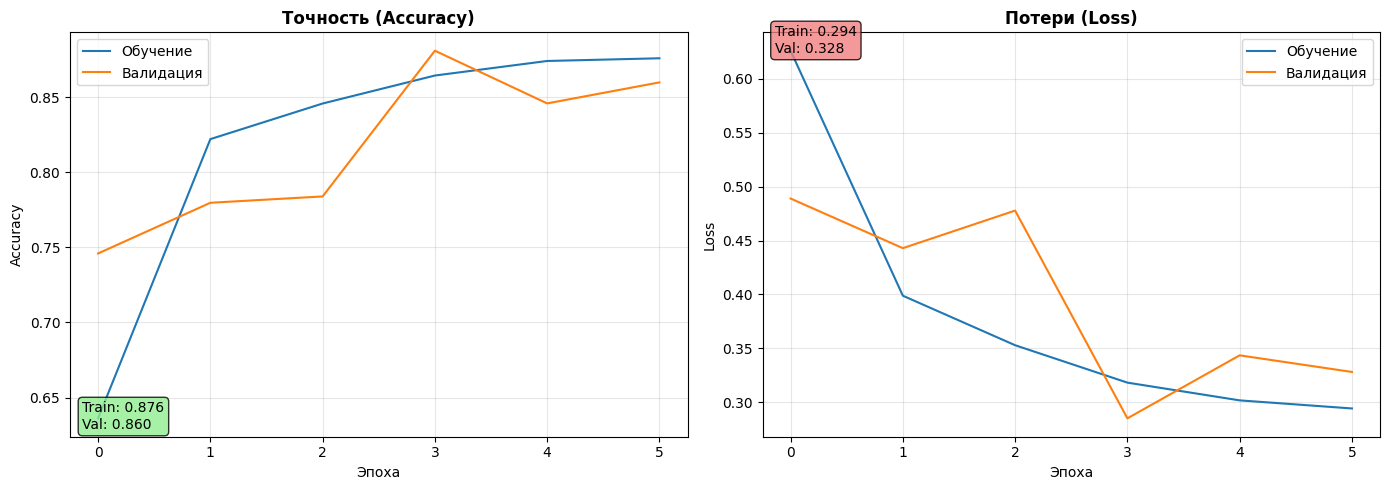

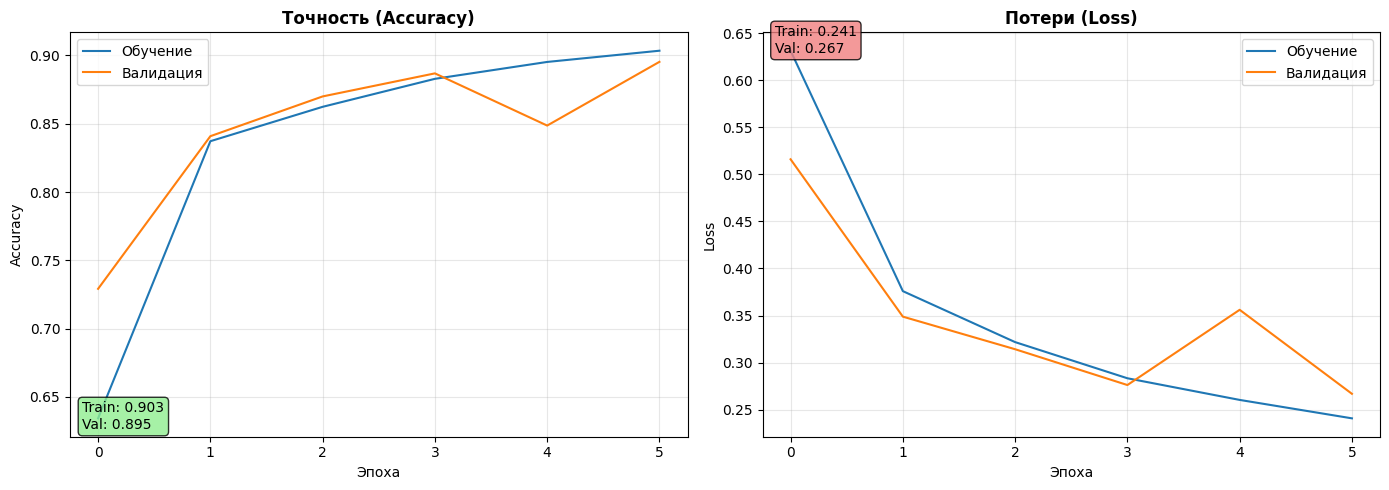

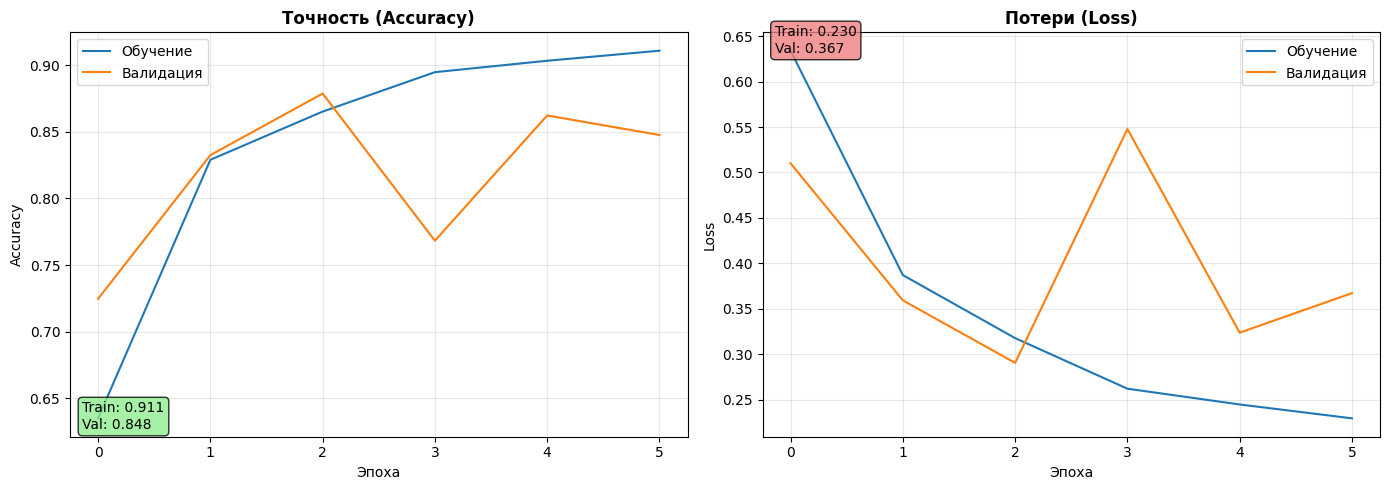

In [53]:
for dim in num_words_list:
  plot_training_history(results[dim]["history"])

  # Пользовательский текст

In [54]:
def encode_text(text, word_index, dimension):
    words = text.lower().split()
    encoded = []

    for word in words:
        index = word_index.get(word)
        if index is not None and index < dimension:
            encoded.append(index)

    vector = np.zeros((1, dimension))
    vector[0, encoded] = 1.0
    return vector

In [55]:
def predict_text(model, text, word_index, dimension=10000):
    vector = encode_text(text, word_index, dimension)

    prediction = model.predict(vector)[0][0]

    print("Текст:", text)
    print("Вероятность положительного отзыва:", prediction)

    if prediction > 0.5:
        print("Результат: ПОЛОЖИТЕЛЬНЫЙ")
    else:
        print("Результат: ОТРИЦАТЕЛЬНЫЙ")

In [57]:
data, targets = load_data(num_words=15000)
data = vectorize_sequences(data, dimension=15000)
targets = np.array(targets).astype("float32")
x_train, y_train, x_test, y_test = split_data(data, targets)

user_text_model = build_model(dim)
history = user_text_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=512,
    validation_split=0.1,
    verbose=0
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
test_loss, test_acc = user_text_model.evaluate(x_test, y_test, verbose=0)

print(f"Точность на тесте: {test_acc:.4f}, Потери: {test_loss:.4f}")

Точность на тесте: 0.8902, Потери: 0.2993


In [59]:
text = input()
predict_text(user_text_model, text, word_index, dimension=15000)

This movie is great amazing wonderful fantastic
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Текст: This movie is great amazing wonderful fantastic
Вероятность положительного отзыва: 0.7660979
Результат: ПОЛОЖИТЕЛЬНЫЙ


In [66]:
print(word_index["terrible"])
print(word_index["awful"])
print(word_index["borin"])
print(word_index["great"])
print(word_index["amazing"])
print(word_index["wonderful"])

391
370
85965
84
477
386


In [71]:
# Хороший отзыв
text1 = "This movie is great amazing wonderful fantastic"
predict_text(user_text_model, text1, word_index, dimension=15000)

# Плохой отзыв
text2 = "This movie is awful"
predict_text(user_text_model, text2, word_index, dimension=15000)

# Нейтральный отзыв
text3 = "The movie was okay"
predict_text(user_text_model, text3, word_index, dimension=15000)

# Противоречивый отзыв
text6 = "The acting was bad but the story was good"
predict_text(user_text_model, text6, word_index, dimension=15000)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
Текст: This movie is great amazing wonderful fantastic
Вероятность положительного отзыва: 0.7660979
Результат: ПОЛОЖИТЕЛЬНЫЙ
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
Текст: This movie is awful
Вероятность положительного отзыва: 0.29600632
Результат: ОТРИЦАТЕЛЬНЫЙ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Текст: The movie was okay
Вероятность положительного отзыва: 0.5456581
Результат: ПОЛОЖИТЕЛЬНЫЙ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Текст: The acting was bad but the story was good
Вероятность положительного отзыва: 0.42340833
Результат: ОТРИЦАТЕЛЬНЫЙ
